# SCRFD with SPOS

This notebook implements the first stage of SPOS for neuron architecture search (NAS) task on face detection, it follows the strategies of SCRFD which are:
- Sample redistribution of hard data samples
- Flop constraning (in my case <= 2.5 GFlop)

To confirm the results claimed in SCRFD research paper of how computational power should be distributed on the network for the task of Face Detection, especially small and dense face detection.

## Paper: 
Single Path One-Shot Neural Architecture Search with Uniform Sampling (SPOS): https://arxiv.org/abs/1904.00420

Sample and Computation Redistribution for Efficient Face Detection (SCRFD): https://arxiv.org/abs/2105.04714

## Notebooks:
- Inferencing and searching stage (second stage): https://www.kaggle.com/code/meowluvmatcha/scrfd-spos-nas-and-inference

## Disclaimer: 
- This is a course project of reproducing the resuls of srcfd paper, so we are not trying to archive the best result here.

# Basic EDA of the Wider face dataset

In [1]:
import os
from scipy.io import loadmat

def parse_wider_face_annotations(mat_path, image_dir):
    # Kiểm tra file mat có tồn tại không để tránh lỗi treo code
    if not os.path.exists(mat_path):
        print(f"❌ Error: Không tìm thấy file annotation tại {mat_path}")
        return []

    mat = loadmat(mat_path)
    dataset_list = []

    event_list = mat['event_list']
    file_list = mat['file_list']
    face_bbx_list = mat['face_bbx_list']

    for i, event in enumerate(event_list):
        directory = event[0][0]
        for j, file in enumerate(file_list[i][0]):
            file_name = file[0][0]
            # Trên Kaggle, đường dẫn ảnh thường là: image_dir + event_directory + file_name.jpg
            image_path = os.path.join(image_dir, directory, file_name + '.jpg')

            # Parse bounding boxes
            bboxes_raw = face_bbx_list[i][0][j][0]
            bboxes = []
            
            # Lọc bỏ các ảnh không có mặt nào (nếu cần) hoặc xử lý lỗi dữ liệu
            if len(bboxes_raw) == 0:
                continue

            for bbox_data in bboxes_raw:
                # WIDER FACE format: x, y, w, h
                x, y, w, h = bbox_data[:4]
                # Loại bỏ các box lỗi (w hoặc h <= 0)
                if w > 0 and h > 0:
                    bboxes.append([float(x), float(y), float(w), float(h)])

            if len(bboxes) > 0:
                dataset_list.append({
                    'image_path': image_path,
                    'faces': {
                        'bbox': bboxes
                    }
                })
                
    return dataset_list

# --- THIẾT LẬP ĐƯỜNG DẪN TRÊN KAGGLE ---
# Lưu ý: Thay 'wider-face' bằng tên chính xác của dataset bạn đã add vào Kaggle
KAGGLE_INPUT_DIR = '/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset' 

train_image_dir = os.path.join(KAGGLE_INPUT_DIR, 'WIDER_train/WIDER_train/images')
val_image_dir = os.path.join(KAGGLE_INPUT_DIR, 'WIDER_val/WIDER_val/images')
train_mat_path = os.path.join(KAGGLE_INPUT_DIR, 'wider_face_annotations/wider_face_split/wider_face_train.mat')
val_mat_path = os.path.join(KAGGLE_INPUT_DIR, 'wider_face_annotations/wider_face_split/wider_face_val.mat')
print("🚀 Đang khởi tạo Dataset trên môi trường Kaggle...")

train_data_list = parse_wider_face_annotations(train_mat_path, train_image_dir)
validation_data_list = parse_wider_face_annotations(val_mat_path, val_image_dir)

dataset = {
    'train': train_data_list,
    'validation': validation_data_list,
    'test': []
}

# /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations


print(f"\n✅ Xong! Tổng cộng: {len(dataset['train'])} ảnh train.")
# Kiểm tra thử 1 đường dẫn để chắc chắn code đúng
if len(dataset['train']) > 0:
    print(f"🔗 Ví dụ đường dẫn ảnh: {dataset['train'][0]['image_path']}")

🚀 Đang khởi tạo Dataset trên môi trường Kaggle...

✅ Xong! Tổng cộng: 12876 ảnh train.
🔗 Ví dụ đường dẫn ảnh: /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_train/WIDER_train/images/0--Parade/0_Parade_marchingband_1_849.jpg


In [2]:
# Cần phải định nghĩa lại train_data vì dataset bây giờ là một dictionary Python thông thường, không phải đối tượng Dataset từ thư viện datasets.
train_data = dataset['train']

# Sau khi chạy các cell trên, bạn có thể chạy lại các cell từ Cell 2 trở đi.

# 📊 Cell 2: EDA Cơ bản - Khám phá cấu trúc dữ liệu

In [3]:
train_data = dataset['train']

print("--- THỐNG KÊ SỐ LƯỢNG ẢNH ---")
print(f"Tập Train:      {len(train_data)} ảnh")
print(f"Tập Validation: {len(dataset['validation'])} ảnh")
print(f"Tập Test:       {len(dataset['test'])} ảnh")

# Khám phá một mẫu (sample) dữ liệu
sample = train_data[0]
print("\n--- CẤU TRÚC DỮ LIỆU CỦA 1 ẢNH ---")
print("Các trường thông tin (keys):", list(sample.keys()))

print("\nChi tiết nhãn (labels) của các khuôn mặt trong ảnh đầu tiên:")
# Trường 'faces' là một dictionary chứa danh sách các thuộc tính
for key, value in sample['faces'].items():
    print(f"- {key}: {value}")

--- THỐNG KÊ SỐ LƯỢNG ẢNH ---
Tập Train:      12876 ảnh
Tập Validation: 3222 ảnh
Tập Test:       0 ảnh

--- CẤU TRÚC DỮ LIỆU CỦA 1 ẢNH ---
Các trường thông tin (keys): ['image_path', 'faces']

Chi tiết nhãn (labels) của các khuôn mặt trong ảnh đầu tiên:
- bbox: [[449.0, 330.0, 122.0, 149.0]]


# 🖼️ Cell 3: EDA Nâng cao - Trực quan hóa Bounding Box

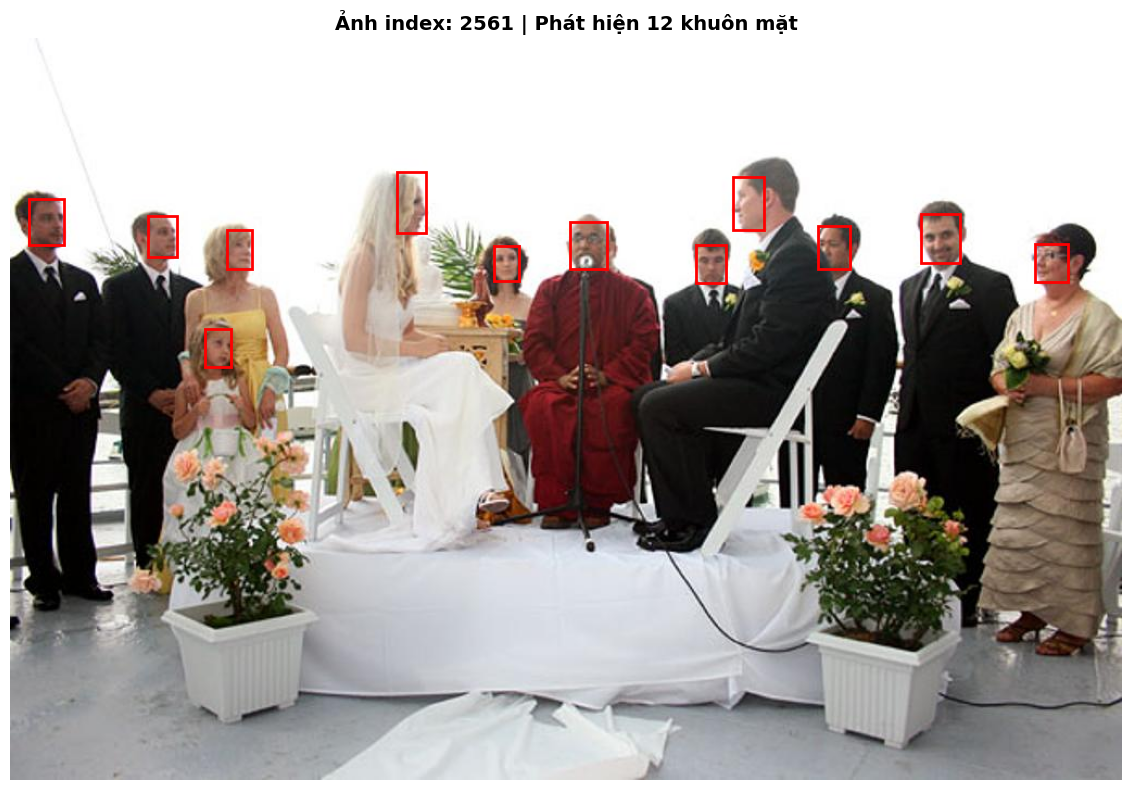

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from PIL import Image

def visualize_random_faces(data_split):
    # Lấy ngẫu nhiên 1 mẫu
    idx = random.randint(0, len(data_split) - 1)
    sample = data_split[idx]

    image_path = sample['image_path'] # Lấy đường dẫn hình ảnh
    img = Image.open(image_path).convert('RGB') # Tải hình ảnh khi cần
    bboxes = sample['faces']['bbox'] # Danh sách các bounding box

    # Thiết lập biểu đồ
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)
    ax.axis('off')

    # Vẽ từng bounding box lên ảnh
    for bbox in bboxes:
        x, y, w, h = bbox
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor='#FF0000', facecolor='none'
        )
        ax.add_patch(rect)

    plt.title(f"Ảnh index: {idx} | Phát hiện {len(bboxes)} khuôn mặt", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chạy thử 2 lần để xem các ảnh ngẫu nhiên khác nhau
visualize_random_faces(train_data)

# ✂️ Cell 4 (Bonus): Chuẩn bị Subset cho bước NAS (SPOS) + Sample Redistribution

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

def get_sr_subset(data_list, subset_ratio=0.5, small_face_threshold=32*32):
    """
    Thực hiện Sample Redistribution bằng cách phân loại ảnh dựa trên độ khó (kích thước mặt)
    """
    hard_samples = []  # Ảnh chứa nhiều mặt nhỏ
    easy_samples = []  # Ảnh chỉ chứa mặt lớn hoặc ít mặt
    
    for item in data_list:
        bboxes = item['faces']['bbox']
        # Tính diện tích các khuôn mặt trong ảnh
        areas = [w * h for (_, _, w, h) in bboxes]
        
        # Nếu ảnh có bất kỳ mặt nào nhỏ hơn ngưỡng (ví dụ 32x32) 
        # hoặc có số lượng mặt lớn (> 10 mặt), ta coi là 'hard'
        if any(a < small_face_threshold for a in areas) or len(bboxes) > 10:
            hard_samples.append(item)
        else:
            easy_samples.append(item)
            
    print(f"📊 Phân tích SR: Tìm thấy {len(hard_samples)} ảnh khó và {len(easy_samples)} ảnh dễ.")
    
    # Tính toán số lượng mẫu cần lấy
    total_needed = int(len(data_list) * subset_ratio)
    
    # Ưu tiên lấy TẤT CẢ các mẫu khó trước
    if len(hard_samples) >= total_needed:
        sr_subset = hard_samples[:total_needed]
    else:
        # Nếu mẫu khó không đủ, lấy toàn bộ mẫu khó và bù thêm bằng mẫu dễ
        needed_easy = total_needed - len(hard_samples)
        sr_subset = hard_samples + easy_samples[:needed_easy]
        
    return sr_subset

# 1. Thực hiện lấy subset theo triết lý SR
# Thay vì test mù quáng, ta lấy 50% nhưng là 50% "chất lượng/khó" nhất
nas_subset = get_sr_subset(dataset['train'], subset_ratio=0.5)

# 2. Xáo trộn lại để đảm bảo tính ngẫu nhiên khi train
import random
random.seed(42)
random.shuffle(nas_subset)

print(f"✅ Đã chuẩn bị Subset theo SR!")
print(f"🚀 Số lượng ảnh gốc: {len(dataset['train'])}")
print(f"🎯 Số lượng ảnh sau SR: {len(nas_subset)}")

📊 Phân tích SR: Tìm thấy 4831 ảnh khó và 8045 ảnh dễ.
✅ Đã chuẩn bị Subset theo SR!
🚀 Số lượng ảnh gốc: 12876
🎯 Số lượng ảnh sau SR: 6438


# Defining the search space

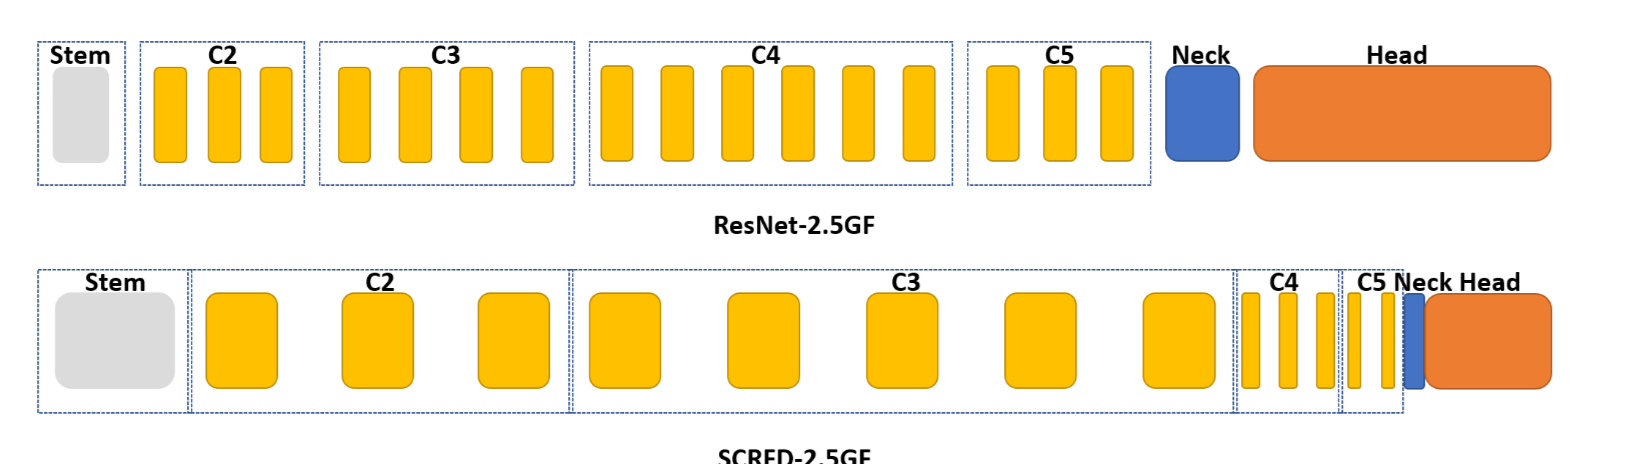

First, the SCRFD paper fixs thier achitecture design by following the combines of blocks of RetinaFace. Which includes:

- The stem
- The backbone, which has for stages
- The neck, which is Path Agregrated Pyramid network
- The head

At each those part, the origin paper search for:
- At the backbone, the depth and width (the number of blocks and chanels of each block) for each stages
- The number of channels of the head and neck. 

## Limit the space

Due to limited resources, we employed the following strategies to make **OUR** search space smaller and more managable, but still general enough to gain insight.

- Chanels limit: According SCRFD paper, we know in advance that the most of computational power should be allocated for the C2 and C3 layer, so I let the first 2 layers search for larger config and the later layers will search for smaller config.

- If we see the network tends to lower of computation of the early layers or put more to the latter layers we will consider it as a sign to check. Also E made the search ranges overlap for better generalization.

- Chanels Depth limit: We limit the depth of each stage of the backbone to 5

- Part limit: Follow the SCRFD paper, we fix the settings of head and neck, only perform the search on the backbone configuration

In [6]:
import torch
import torch.nn as nn
import random

# 2d search space
SEARCH_SPACE = {
    'C2_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)], 
    'C3_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)],   
    'C4_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)],    
    'C5_channels': [(w * 8, d) for w in range(1, 16) for d in range(1, 5)]      
}


# SEARCH_SPACE = {
#     'C2_channels': [(w * 16, d) for w in range(7, 8) for d in range(4, 5)], 
#     'C3_channels': [(w * 16, d) for w in range(11, 12) for d in range(4, 5)],   
#     'C4_channels': [(w * 16, d) for w in range(9, 10) for d in range(4, 5)],    
#     'C5_channels': [(w * 16, d) for w in range(5, 6) for d in range(4, 5)]      
# }


print("Đã load cấu hình Search Space!")

Đã load cấu hình Search Space!


# Network definition

SCRFD constraining their architecture by GFLOP, and they choosed MobileNetV2 for their 2.5GFlop configuration.

In this work, we use the architecture consists of:
- Backbone: follows MobileNetV2 and the SCRFD paper
- Neck: Path agrerated pyramid network
- Head: Heatmap-only head

We acknowledged the original RetinaFace uses the focal-loss with multiple branches to learn from. We only use the produced heatmap as our main outputs as it simplifies and speeds up the training process.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import math

class DynamicConv2d(nn.Module):
    """Lớp Tích chập tự động cắt trọng số (Weight Slicing)"""
    def __init__(self, max_in_channels, max_out_channels, kernel_size=1, stride=1, padding=0, groups=1):
        super(DynamicConv2d, self).__init__()
        # Khởi tạo ma trận trọng số LỚN NHẤT
        self.weight = nn.Parameter(torch.Tensor(max_out_channels, max_in_channels // groups, kernel_size, kernel_size))
        self.bias = nn.Parameter(torch.Tensor(max_out_channels))
        
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        nn.init.zeros_(self.bias)

        self.stride = stride
        self.padding = padding
        self.groups = groups

    def forward(self, x, active_out_c):
        in_c = x.shape[1] # Tự động nhận diện số kênh thực tế của đầu vào
        out_c = active_out_c
        
        # Xử lý tự động cho Depthwise Convolution (groups > 1)
        active_groups = in_c if self.groups > 1 else 1

        # CẮT TRỌNG SỐ: Chỉ lấy 1 góc của ma trận trọng số (Phần lõi)
        active_weight = self.weight[:out_c, :in_c // active_groups, :, :]
        active_bias = self.bias[:out_c]

        return F.conv2d(x, active_weight, active_bias, self.stride, self.padding, groups=active_groups)

# class DynamicBatchNorm2d(nn.Module):
#     """Lớp Batch Norm tự động cắt trọng số"""
#     def __init__(self, max_channels):
#         super(DynamicBatchNorm2d, self).__init__()
#         self.bn = nn.BatchNorm2d(max_channels)

#     def forward(self, x):
#         c = x.shape[1] # Cắt đúng số kênh đang hoạt động
#         weight = self.bn.weight[:c]
#         bias = self.bn.bias[:c]
#         rm = self.bn.running_mean[:c]
#         rv = self.bn.running_var[:c]

#         return F.batch_norm(x, rm, rv, weight, bias, self.bn.training, self.bn.momentum, self.bn.eps)

class DynamicBatchNorm2d(nn.Module):
    """Lớp Batch Norm tự động cắt trọng số và chống nhiễu thống kê cho NAS"""
    def __init__(self, max_channels):
        super(DynamicBatchNorm2d, self).__init__()
        self.bn = nn.BatchNorm2d(max_channels)

    def forward(self, x):
        c = x.shape[1] 
        weight = self.bn.weight[:c]
        bias = self.bn.bias[:c]

        if self.training:
            # PHA 1 (Train): Tính trên Batch hiện tại và cập nhật Running Stats bình thường
            rm = self.bn.running_mean[:c]
            rv = self.bn.running_var[:c]
            return F.batch_norm(x, rm, rv, weight, bias, True, self.bn.momentum, self.bn.eps)
        else:
            # PHA 2 (Validation): TRICK QUAN TRỌNG
            # Bỏ qua hoàn toàn Running Stats (vì nó bị nhiễu thập cẩm).
            # Ép PyTorch tính Mean/Var trực tiếp trên chính Batch Validation đang test.
            # (Lưu ý: Yêu cầu batch_size của val_loader phải > 1)
            return F.batch_norm(x, None, None, weight, bias, True, 0.0, self.bn.eps)

In [8]:
class DynamicInvertedResidual(nn.Module):
    """Block Inverted Residual dùng Weight Slicing"""
    def __init__(self, max_in_channels, max_out_channels, stride, expand_ratio=4):
        super(DynamicInvertedResidual, self).__init__()
        max_hidden_dim = int(max_in_channels * expand_ratio)

        # 1. Lớp Expand (1x1)
        self.conv1 = DynamicConv2d(max_in_channels, max_hidden_dim, kernel_size=1)
        self.bn1 = DynamicBatchNorm2d(max_hidden_dim)

        # 2. Lớp Depthwise (3x3)
        self.conv2 = DynamicConv2d(max_hidden_dim, max_hidden_dim, kernel_size=3, stride=stride, padding=1, groups=max_hidden_dim)
        self.bn2 = DynamicBatchNorm2d(max_hidden_dim)

        # 3. Lớp Project (1x1)
        self.conv3 = DynamicConv2d(max_hidden_dim, max_out_channels, kernel_size=1)
        self.bn3 = DynamicBatchNorm2d(max_out_channels)
        self.stride = stride

    def forward(self, x, active_out_channels):
        in_c = x.shape[1]
        active_hidden_dim = in_c * 4 # Tính toán số kênh ẩn tương ứng với kênh đầu vào

        out = self.conv1(x, active_hidden_dim)
        out = self.bn1(out)
        out = F.relu6(out, inplace=True)

        out = self.conv2(out, active_hidden_dim)
        out = self.bn2(out)
        out = F.relu6(out, inplace=True)

        out = self.conv3(out, active_out_channels)
        out = self.bn3(out)

        # Skip connection (Chỉ cộng khi cùng số kênh và stride = 1)
        if self.stride == 1 and in_c == active_out_channels:
            return x + out
        return out

In [9]:


class ConvBNReLU(nn.Module):
    """Khối Convolution cơ bản kèm Batch Norm và ReLU"""
    def __init__(self, in_planes, out_planes, kernel_size=3, stride=1, groups=1):
        padding = (kernel_size - 1) // 2
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size, stride, padding, groups=groups, bias=False)
        self.bn = nn.BatchNorm2d(out_planes)
        self.relu = nn.ReLU6(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class InvertedResidual(nn.Module):
    """Viên gạch cơ bản của MobileNetV2"""
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = self.stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            # Point-wise (Mở rộng số kênh)
            layers.append(ConvBNReLU(inp, hidden_dim, kernel_size=1))
        layers.extend([
            # Depth-wise (Trích xuất đặc trưng)
            ConvBNReLU(hidden_dim, hidden_dim, stride=stride, groups=hidden_dim),
            # Point-wise Linear (Thu hẹp số kênh)
            nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
            nn.BatchNorm2d(oup),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

# SPOS Idea

The search process of SCRFD is too computationally expensive for us, so we adapt Sigle Path One-Shot NAS. Which will put all the possible, predified blocks that will be used for the final architecture to form a Supernet. And we will perform 2 stages on this super net.

## Stage 1 - Training

This Supernet will be train on the data, and at each pass, it will randomly choosing a block from each stages to forward and backpropagation.

As the predified search space, each block will be defined by a pair of (W, D), *channel size and number of inverted residual block*,

At this stage, we will expected every possible combination of single path will be all converge. The neck and the head will be shared among all of the paths.

*Note:* I once worry about the resulting neck and head weight will be negatively afftected by constantly getting updated by different architectures. But, intuitively, if we consider the inputs that minimize the neck+head network's loss, that will be our expected input feature maps, and we want all of the backbone network will learn that distribution.  


## Stage 2 - Neuron Architecture Search

In the SCRFD paper, this process was, they find a architecture, then they train it and evaluating it. In this work, because we randomly trained on the previous step so we will only do the inference on that architecture to get the results.

And report the best model, with the overall trend of distribution.

In [10]:

class DynamicChoiceBlock(nn.Module):
    """Khối SPOS chuẩn: Xử lý cả Width Slicing và Depth Drop"""
    def __init__(self, max_in_channels, options_list, stride):
        super(DynamicChoiceBlock, self).__init__()
        self.options_list = options_list

        # Tìm năng lực TỐI ĐA (Max Capacity) để cấp phát RAM
        self.max_width = max([w for w, d in options_list])
        self.max_depth = max([d for w, d in options_list])

        self.blocks = nn.ModuleList()
        for i in range(self.max_depth):
            s = stride if i == 0 else 1
            # Block đầu tiên nhận max_in_channels từ tầng trước. 
            # Các block sau nhận max_width của chính khối này.
            inp = max_in_channels if i == 0 else self.max_width
            self.blocks.append(
                DynamicInvertedResidual(inp, self.max_width, stride=s, expand_ratio=4)
            )

    def forward(self, x):
        if self.training:
            # PHA 1 (Train): Bốc ngẫu nhiên 1 đường cấu hình
            active_width, active_depth = random.choice(self.options_list)
        else:
            # PHA 2 (Search): Đi theo cấu hình được chỉ định (mặc định lấy max nếu chưa set)
            active_width = getattr(self, 'active_width', self.max_width)
            active_depth = getattr(self, 'active_depth', self.max_depth)

        # SEARCH CHIỀU SÂU: Chỉ chạy qua số block bằng với active_depth
        for i in range(active_depth):
            # Block tự động cắt trọng số theo active_width
            x = self.blocks[i](x, active_width)

        return x

class SPOS_Backbone(nn.Module):
    """Supernet Backbone tối ưu, KHÔNG DÙNG PADDING"""
    def __init__(self, search_space):
        super(SPOS_Backbone, self).__init__()

        # Stem mặc định (Cần phải viết lại thành DynamicConv2d nếu bạn cũng muốn search Stem)
        # Ở đây giữ nguyên tĩnh theo code cũ của bạn
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU6(inplace=True)
        )

        def get_max_width(options):
            return max([width for width, depth in options])

        # Các tầng tự động liên kết với nhau bằng kích thước Tối Đa
        self.c2 = DynamicChoiceBlock(16, search_space['C2_channels'], stride=2)
        
        c2_max = get_max_width(search_space['C2_channels'])
        self.c3 = DynamicChoiceBlock(c2_max, search_space['C3_channels'], stride=2)
        
        c3_max = get_max_width(search_space['C3_channels'])
        self.c4 = DynamicChoiceBlock(c3_max, search_space['C4_channels'], stride=2)
        
        c4_max = get_max_width(search_space['C4_channels'])
        self.c5 = DynamicChoiceBlock(c4_max, search_space['C5_channels'], stride=2)

    def forward(self, x):
        c1 = self.stem(x)
        c2 = self.c2(c1)
        c3 = self.c3(c2)
        c4 = self.c4(c3)
        c5 = self.c5(c4)

        return [c2, c3, c4, c5]

In [11]:

# --- TEST THỬ MÔ HÌNH ---
# Khởi tạo mô hình
supernet_backbone = SPOS_Backbone(SEARCH_SPACE)

# Tạo một tensor ảnh giả định (Batch=2, Channels=3, Height=640, Width=640)
dummy_input = torch.randn(2, 3, 640, 640)

# Chạy thử
supernet_backbone.train() # Bật chế độ random SPOS
features = supernet_backbone(dummy_input)

print("\nĐã chạy Forward Pass qua Supernet thành công!")
print("Kích thước các Feature Maps trả về (Chuẩn bị cho Neck):")
for i, feat in enumerate(features):
    print(f"C{i+2}: {feat.shape}")


Đã chạy Forward Pass qua Supernet thành công!
Kích thước các Feature Maps trả về (Chuẩn bị cho Neck):
C2: torch.Size([2, 24, 160, 160])
C3: torch.Size([2, 104, 80, 80])
C4: torch.Size([2, 96, 40, 40])
C5: torch.Size([2, 112, 20, 20])


In [12]:
import torch.nn.functional as F

class SharedPAFPN(nn.Module):
    """Khối Neck (PAFPN) dùng chung cho mọi Backbone"""
    def __init__(self, in_channels_list, out_channels=64):
        super(SharedPAFPN, self).__init__()
        self.in_channels_list = in_channels_list

        # 1. Lateral Layers (Chuyển đổi số kênh của C2, C3, C4, C5 về chung 1 chuẩn out_channels)
        self.lat_c2 = nn.Conv2d(in_channels_list[0], out_channels, 1)
        self.lat_c3 = nn.Conv2d(in_channels_list[1], out_channels, 1)
        self.lat_c4 = nn.Conv2d(in_channels_list[2], out_channels, 1)
        self.lat_c5 = nn.Conv2d(in_channels_list[3], out_channels, 1)

        # 2. Downsample Layers (Dùng cho nhánh Bottom-Up của PAFPN)
        self.down_p2 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)
        self.down_p3 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)
        self.down_p4 = nn.Conv2d(out_channels, out_channels, 3, stride=2, padding=1)

    def _align_channels(self, x, expected_c):
        """Hàm đệm thêm số 0 nếu Backbone xuất ra ít kênh hơn mức tối đa"""
        B, C, H, W = x.shape
        if C < expected_c:
            padding = torch.zeros(B, expected_c - C, H, W, device=x.device)
            x = torch.cat([x, padding], dim=1)
        return x

    def forward(self, features):
        c2, c3, c4, c5 = features

        # Đệm kênh cho chuẩn
        c2 = self._align_channels(c2, self.in_channels_list[0])
        c3 = self._align_channels(c3, self.in_channels_list[1])
        c4 = self._align_channels(c4, self.in_channels_list[2])
        c5 = self._align_channels(c5, self.in_channels_list[3])

        # Chuyển đổi về chung 1 số kênh (vd: 64)
        l2, l3, l4, l5 = self.lat_c2(c2), self.lat_c3(c3), self.lat_c4(c4), self.lat_c5(c5)

        # --- Nhánh Top-Down (FPN truyền thống) ---
        p5 = l5
        p4 = l4 + F.interpolate(p5, size=l4.shape[-2:], mode='nearest')
        p3 = l3 + F.interpolate(p4, size=l3.shape[-2:], mode='nearest')
        p2 = l2 + F.interpolate(p3, size=l2.shape[-2:], mode='nearest')

        # --- Nhánh Bottom-Up (PAFPN mở rộng) ---
        n2 = p2
        n3 = p3 + self.down_p2(n2)
        n4 = p4 + self.down_p3(n3)
        n5 = p5 + self.down_p4(n4)

        return [n2, n3, n4, n5]

class ProxyHeatmapHead(nn.Module):
    """Khối Head ủy quyền tối giản: Chỉ dự đoán 1 kênh Heatmap"""
    def __init__(self, in_channels=64, feature_channels=96):
        super(ProxyHeatmapHead, self).__init__()
        
        # Trích xuất đặc trưng có GroupNorm để ổn định NAS
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels, feature_channels, kernel_size=3, padding=1),
            nn.GroupNorm(32, feature_channels),
            nn.ReLU(inplace=True)
        )
        
        # XUẤT RA 1 KÊNH DUY NHẤT (Logits thô)
        self.heatmap_out = nn.Conv2d(feature_channels, 1, kernel_size=1)
        # =========================================================
        # FIX QUAN TRỌNG: Khởi tạo Prior Probability cho Focal Loss
        # =========================================================
        prior_prob = 0.01  # Bắt đầu với niềm tin "chỉ 1% pixel là mặt người"
        bias_value = -math.log((1.0 - prior_prob) / prior_prob)
        
        # Khởi tạo trọng số nhẹ nhàng và gán Bias để chống nổ Loss
        nn.init.normal_(self.heatmap_out.weight, std=0.01)
        nn.init.constant_(self.heatmap_out.bias, bias_value)

    
    def forward(self, pafpn_features):
        outputs = []
        for feat in pafpn_features[1:]: 
            x = self.feature_extractor(feat)
            out = self.heatmap_out(x)
            
            # TRẢ VỀ RAW LOGITS (Tuyệt đối không dùng torch.sigmoid ở đây)
            outputs.append(out) 
        return outputs
# =========================================
# LẮP RÁP VÀ TEST TỔNG THỂ MÔ HÌNH SUPERNET
# =========================================

# Xác định số kênh LỚN NHẤT từ Search Space để Neck chuẩn bị hứng
max_channels = [
    SEARCH_SPACE['C2_channels'][-1][0], # 32
    SEARCH_SPACE['C3_channels'][-1][0], # 64
    SEARCH_SPACE['C4_channels'][-1][0], # 80
    SEARCH_SPACE['C5_channels'][-1][0]  # 128
]

# Khởi tạo Neck và Head
neck = SharedPAFPN(in_channels_list=max_channels, out_channels=32)
head = ProxyHeatmapHead(in_channels=32, feature_channels=96)

# Kết nối luồng dữ liệu (Sử dụng lại outputs 'features' từ bước trước)
pafpn_outs = neck(features)
heatmaps_outs = head(pafpn_outs)

print("Đã chạy thành công qua toàn bộ mô hình Supernet!")
print("Kích thước Bản đồ nhiệt (Heatmaps) đầu ra:")
for i, hm in enumerate(heatmaps_outs):
    # Kết quả kỳ vọng: [Batch=2, Channels=1, Height, Width]
    print(f"Scale {i+1} (stride {2**(i+2)}): {hm.shape}")

Đã chạy thành công qua toàn bộ mô hình Supernet!
Kích thước Bản đồ nhiệt (Heatmaps) đầu ra:
Scale 1 (stride 4): torch.Size([2, 1, 80, 80])
Scale 2 (stride 8): torch.Size([2, 1, 40, 40])
Scale 3 (stride 16): torch.Size([2, 1, 20, 20])


# Prepare the data

- We prepare the data by precompute the transformed images so the cpu only need to do the read operation on training time.

- We create 3 strides of heatmap, [8, 16, 32] because the paper skips the C2 heat map 

In [13]:
import os
import torch
import torchvision.transforms.functional as TF
from PIL import Image
import time
import numpy as np

# Tạo thư mục chứa dữ liệu đã chế biến
SAVE_DIR = "/kaggle/working/widerface_cached"
os.makedirs(SAVE_DIR, exist_ok=True)

# Lấy lại hàm _create_heatmap từ các bước trước
def _create_heatmap(target_size, bboxes, stride, orig_w, orig_h):
    heatmap = torch.zeros((1, target_size[0], target_size[1]), dtype=torch.float32)
    scale_x = 640 / orig_w
    scale_y = 640 / orig_h
    for bbox in bboxes:
        x_min, y_min, w, h = bbox
        if w < 2 or h < 2: continue
        center_x = (x_min + w / 2) * scale_x
        center_y = (y_min + h / 2) * scale_y
        grid_x, grid_y = int(center_x / stride), int(center_y / stride)
        if 0 <= grid_x < target_size[1] and 0 <= grid_y < target_size[0]:
            heatmap[0, grid_y, grid_x] = 1.0
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    nx, ny = grid_x + dx, grid_y + dy
                    if (dx != 0 or dy != 0) and 0 <= nx < target_size[1] and 0 <= ny < target_size[0]:
                        if heatmap[0, ny, nx] == 0: heatmap[0, ny, nx] = 0.5
    return heatmap

print("🏭 BẮT ĐẦU CHẾ BIẾN VÀ LƯU DỮ LIỆU NGOẠI TUYẾN...")
start_time = time.time()
saved_count = 0

for idx in range(len(nas_subset)):
    sample = nas_subset[idx]
    img_path = sample['image_path']
    bboxes = sample['faces']['bbox']

    # 1. MỞ ẢNH VÀ RESIZE
    img = Image.open(img_path).convert("RGB")
    orig_w, orig_h = img.size
    img_resized = img.resize((640, 640), Image.BILINEAR)

    # --- BẢN 1: ẢNH GỐC ---
    hm_orig = [_create_heatmap((640//s, 640//s), bboxes, s, orig_w, orig_h).half() for s in [8, 16, 32]]

    # Lưu Bản gốc
    img_resized.save(f"{SAVE_DIR}/{saved_count}_img.jpg")
    torch.save(hm_orig, f"{SAVE_DIR}/{saved_count}_hm.pt")
    saved_count += 1

    # --- BẢN 2: ẢNH LẬT NGANG (AUGMENTATION) ---
    img_flipped = TF.hflip(img_resized)

    # Toán học: Khi lật ngang ảnh, tọa độ X của khuôn mặt cũng phải lật ngược lại
    flipped_bboxes = []
    for bbox in bboxes:
        x, y, w, h = bbox
        new_x = orig_w - x - w # Công thức dời trục X
        flipped_bboxes.append([new_x, y, w, h])

    hm_flipped = [_create_heatmap((640//s, 640//s), flipped_bboxes, s, orig_w, orig_h).half() for s in [8, 16, 32]]

    # Lưu Bản lật
    img_flipped.save(f"{SAVE_DIR}/{saved_count}_img.jpg")
    torch.save(hm_flipped, f"{SAVE_DIR}/{saved_count}_hm.pt")
    saved_count += 1

    if saved_count % 1000 == 0:
        print(f"Đã lưu {saved_count} mẫu...")
        # break
print(f"✅ Hoàn tất! Đã tạo và lưu {saved_count} mẫu. Thời gian: {time.time() - start_time:.2f}s")

🏭 BẮT ĐẦU CHẾ BIẾN VÀ LƯU DỮ LIỆU NGOẠI TUYẾN...
Đã lưu 1000 mẫu...
Đã lưu 2000 mẫu...
Đã lưu 3000 mẫu...
Đã lưu 4000 mẫu...
Đã lưu 5000 mẫu...
Đã lưu 6000 mẫu...
Đã lưu 7000 mẫu...
Đã lưu 8000 mẫu...
Đã lưu 9000 mẫu...
Đã lưu 10000 mẫu...
Đã lưu 11000 mẫu...
Đã lưu 12000 mẫu...
✅ Hoàn tất! Đã tạo và lưu 12876 mẫu. Thời gian: 305.97s


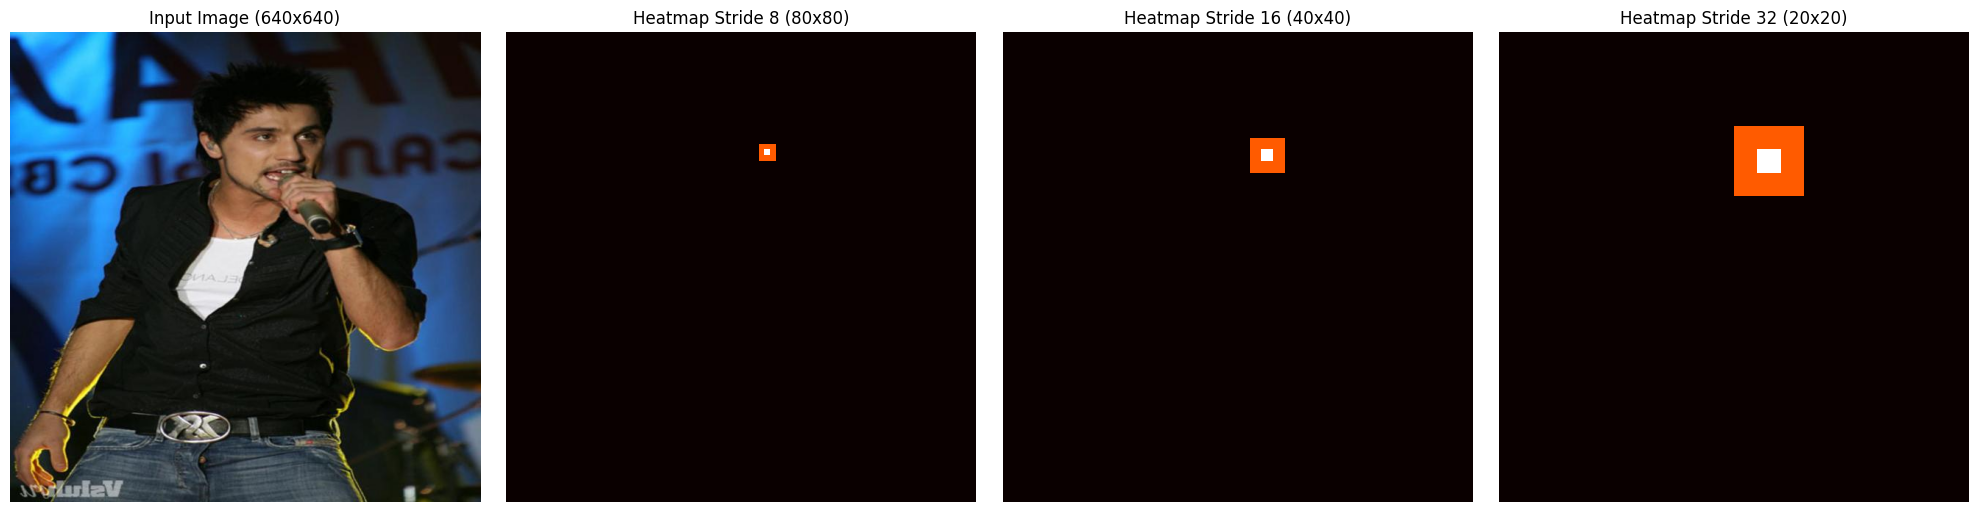

In [14]:
import matplotlib.pyplot as plt
import torch
from PIL import Image
import random
# 1. Chọn một mẫu để hiển thị (ví dụ mẫu số 0)
sample_idx = random.randint(0, saved_count - 1)
img_path = f"{SAVE_DIR}/{sample_idx}_img.jpg"
hm_path = f"{SAVE_DIR}/{sample_idx}_hm.pt"

# 2. Tải ảnh và heatmap
img = Image.open(img_path)
heatmaps = torch.load(hm_path) # Danh sách [hm_stride8, hm_stride16, hm_stride32]

# 3. Vẽ biểu đồ minh họa
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# --- Ảnh gốc ---
axes[0].imshow(img)
axes[0].set_title("Input Image (640x640)")
axes[0].axis('off')

# --- Heatmap Stride 8 (80x80) ---
axes[1].imshow(heatmaps[0][0].float().numpy(), cmap='hot')
axes[1].set_title("Heatmap Stride 8 (80x80)")
axes[1].axis('off')

# --- Heatmap Stride 16 (40x40) ---
axes[2].imshow(heatmaps[1][0].float().numpy(), cmap='hot')
axes[2].set_title("Heatmap Stride 16 (40x40)")
axes[2].axis('off')

# --- Heatmap Stride 32 (20x20) ---
axes[3].imshow(heatmaps[2][0].float().numpy(), cmap='hot')
axes[3].set_title("Heatmap Stride 32 (20x20)")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [15]:
from torch.utils.data import Dataset, DataLoader, random_split
import glob

class FastCachedDataset(Dataset):
    def __init__(self, cache_dir):
        self.cache_dir = cache_dir
        # Tìm tất cả các file ảnh trong thư mục
        self.img_files = sorted(glob.glob(f"{cache_dir}/*_img.jpg"))

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        # Đường dẫn file
        img_path = self.img_files[idx]
        hm_path = img_path.replace("_img.jpg", "_hm.pt")

        # 1. Đọc ảnh và chuyển thành tensor [0, 1]
        img = Image.open(img_path)
        img_tensor = TF.to_tensor(img)

        # 2. Đọc Heatmaps từ file .pt và ép ngược về float32 để tính Loss
        heatmaps_half = torch.load(hm_path, weights_only=True)
        heatmaps = [hm.float() for hm in heatmaps_half]

        return img_tensor, heatmaps



# 1. Khởi tạo dataset từ thư mục cache
full_dataset = FastCachedDataset(SAVE_DIR)

# 2. Chia dữ liệu: 90% train, 10% validation
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# 3. Tạo Train Loader
train_loader = DataLoader(
    train_subset,
    batch_size=16, # Batch size 32 phù hợp cho mức 2.5 GFlops [cite: 135]
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

# 4. Tạo Val Loader
val_loader = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"✅ Đã sẵn sàng: {len(train_subset)} mẫu huấn luyện | {len(val_subset)} mẫu kiểm định.")

✅ Đã sẵn sàng: 11588 mẫu huấn luyện | 1288 mẫu kiểm định.


In [16]:
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class ProxyFocalLossWithLogits(nn.Module):
    """
    Hàm Focal Loss rút gọn, NHẬN LOGITS THÔ ĐẦU VÀO để chống lỗi nan/inf khi dùng AMP.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(ProxyFocalLossWithLogits, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred_logits, targets):
        # pred_logits: Raw outputs chưa qua sigmoid
        # targets: Ground Truth heatmaps
        
        total_loss = 0.0

        for logits, target in zip(pred_logits, targets):
            # BƯỚC 1: BẮT BUỘC ÉP VỀ FP32 ĐỂ TÍNH TOÁN AN TOÀN TRONG AMP
            logits = logits.float()
            target = target.float()

            # BƯỚC 2: TÍNH BCE LOSS BẰNG HÀM C++ CỦA PYTORCH
            # Hàm này tối ưu log-sum-exp toán học, KHÔNG BAO GIỜ bị log(0)
            bce_loss = F.binary_cross_entropy_with_logits(logits, target, reduction='none')

            # BƯỚC 3: TÍNH FOCAL WEIGHT (TRỌNG SỐ PHẠT)
            # Lúc này tính sigmoid trên không gian FP32 là hoàn toàn an toàn
            pred_prob = torch.sigmoid(logits)

            pos_mask = (target > 0).float()
            neg_mask = (target == 0).float()

            # Trọng số cho điểm dương (Mặt người)
            pos_weight = (1.0 - pred_prob)**self.gamma * pos_mask * target
            
            # Trọng số cho điểm âm (Nền)
            neg_weight = pred_prob**self.gamma * neg_mask

            focal_weight = pos_weight + neg_weight

            # BƯỚC 4: KẾT HỢP LOSS VÀ WEIGHT
            num_pos = pos_mask.sum()
            loss_map = focal_weight * bce_loss
            num_pos = torch.clamp(num_pos, min=1.0)
            # Trung bình loss (chia cho số lượng đối tượng, tránh chia 0)
            total_loss += loss_map.sum() / num_pos

        return total_loss

# Khởi tạo hàm Loss
criterion = ProxyFocalLossWithLogits()
print("Đã khởi tạo hàm Proxy Focal Loss thành công!")

Đã khởi tạo hàm Proxy Focal Loss thành công!


# Training

:D I uses the hyperparameters settup and dark magic from Gemini suggestions.

In [17]:
import torch.optim as optim
# from torch.cuda.amp import autocast, GradScaler # Import thư viện tăng tốc AMP
from torch.amp import autocast, GradScaler
import time
# ==========================================
# CÀI ĐẶT THIẾT BỊ VÀ BỘ TỐI ƯU (OPTIMIZER)
# ==========================================

# Kiểm tra xem Colab đã bật GPU chưa
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang huấn luyện trên thiết bị: {device}")

# Đưa toàn bộ mô hình lên GPU
supernet_backbone = supernet_backbone.to(device)
neck = neck.to(device)
head = head.to(device)
criterion = criterion.to(device)

# Gộp tất cả tham số của 3 khối lại để Optimizer quản lý
all_parameters = (list(supernet_backbone.parameters()) +
                  list(neck.parameters()) +
                  list(head.parameters()))

# Sử dụng Adam Optimizer cho Proxy Task để mạng hội tụ nhanh (Learning rate: 0.001)
optimizer = optim.AdamW(all_parameters, lr=2e-4, weight_decay=1e-4)
# ==========================================
# VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP)
# ==========================================

scaler = GradScaler()
num_epochs = 35 # Train thử 15 epoch cho Supernet
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
print("\n🚀 BẮT ĐẦU HUẤN LUYỆN SUPERNET (AMP + SPOS ENABLED) 🚀")

total_batch = len(train_loader)

for epoch in range(num_epochs):
    # ==========================================
    # PHA HUẤN LUYỆN (TRAINING PHASE)
    # ==========================================
    supernet_backbone.train()
    neck.train()
    head.train()
    
    epoch_train_loss = 0.0
    start_time = time.time()
    valid_train_batch = 0
    
    for batch_idx, (images, target_heatmaps) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        target_heatmaps = [tm.to(device, non_blocking=True) for tm in target_heatmaps]

        optimizer.zero_grad()

        with autocast(device.__str__()):
            # Tối ưu hóa tập trung vào tầng nông C2, C3 theo SCRFD [cite: 13, 222]
            features = supernet_backbone(images) 
            pafpn_outs = neck(features)
            pred_heatmaps = head(pafpn_outs)
            loss = criterion(pred_heatmaps, target_heatmaps)
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"⚠️ Bỏ qua Batch {batch_idx} vì Loss bị NaN/Inf!")
            optimizer.zero_grad() # Xóa sạch gradient độc hại
            continue              # Nhảy sang batch tiếp theo luôn

        valid_train_batch += 1
        scaler.scale(loss).backward()
        
        # Gradient clipping chống bùng nổ gradient trong NAS
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(all_parameters, max_norm=2.0)

        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Batch id [{batch_idx + 1} / {valid_train_batch}] | Train Loss: {epoch_train_loss / (batch_idx + 1):.4f}")
  
    # ==========================================
    # PHA KIỂM ĐỊNH (VALIDATION PHASE)
    # ==========================================
    supernet_backbone.eval()
    neck.eval()
    head.eval()
    
    epoch_val_loss = 0.0
    valid_batches = 0 # Đếm số batch hợp lệ để tính trung bình
    
    with torch.no_grad():
        for val_batch_idx, (images, target_heatmaps) in enumerate(val_loader):
            images = images.to(device, non_blocking=True)
            target_heatmaps = [tm.to(device, non_blocking=True) for tm in target_heatmaps]

            with autocast(device.__str__()):
                features = supernet_backbone(images)
                pafpn_outs = neck(features)
                pred_heatmaps = head(pafpn_outs)
                
                v_loss = criterion(pred_heatmaps, target_heatmaps)
            
            # Kiểm tra an toàn cho Validation Loss
            if torch.isnan(v_loss) or torch.isinf(v_loss):
                print(f"⚠️ [Val] Bỏ qua Batch {val_batch_idx} vì v_loss bị NaN/Inf!")
                continue  # Bỏ qua cộng dồn v_loss
            
            epoch_val_loss += v_loss.item()
            valid_batches += 1    
            
    # Cập nhật Learning Rate
            
    scheduler.step()
    
    # Tính toán log
    avg_train_loss = epoch_train_loss / max(1, valid_train_batch)
    avg_val_loss = epoch_val_loss / max(1, valid_batches)
    current_lr = scheduler.get_last_lr()[0]
    duration = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"LR: {current_lr:.6g} | Thời gian: {duration:.2f}s")
    print("-" * 50)

print("🎉 HUẤN LUYỆN HOÀN TẤT. Supernet đã sẵn sàng cho bước Search!")

Đang huấn luyện trên thiết bị: cuda

🚀 BẮT ĐẦU HUẤN LUYỆN SUPERNET (AMP + SPOS ENABLED) 🚀
Epoch [1/35] - Batch id [100 / 100] | Train Loss: 3.9791
Epoch [1/35] - Batch id [200 / 200] | Train Loss: 3.1987
Epoch [1/35] - Batch id [300 / 300] | Train Loss: 2.7361
Epoch [1/35] - Batch id [400 / 400] | Train Loss: 2.4173
Epoch [1/35] - Batch id [500 / 500] | Train Loss: 2.1929
Epoch [1/35] - Batch id [600 / 600] | Train Loss: 2.0365
Epoch [1/35] - Batch id [700 / 700] | Train Loss: 1.9218
Epoch [1/35] | Train Loss: 1.8963 | Val Loss: 1.2034
LR: 0.000199599 | Thời gian: 353.40s
--------------------------------------------------
Epoch [2/35] - Batch id [100 / 100] | Train Loss: 1.1805
Epoch [2/35] - Batch id [200 / 200] | Train Loss: 1.1794
Epoch [2/35] - Batch id [300 / 300] | Train Loss: 1.1759
Epoch [2/35] - Batch id [400 / 400] | Train Loss: 1.1662
Epoch [2/35] - Batch id [500 / 500] | Train Loss: 1.1608
Epoch [2/35] - Batch id [600 / 600] | Train Loss: 1.1512
Epoch [2/35] - Batch id [700

In [18]:
import torch
import os

# 1. Khai báo đường dẫn
save_path = '/kaggle/working/SCRFD_NAS_MODELS'

# 2. KIỂM TRA VÀ TẠO THƯ MỤC (Quan trọng nhất)
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"📁 Đã tạo thư mục mới: {save_path}")

# 3. Gom checkpoint
checkpoint = {
    'epoch': 2,
    'supernet_backbone_state_dict': supernet_backbone.state_dict(),
    'neck_state_dict': neck.state_dict(),
    'head_state_dict': head.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'search_space': SEARCH_SPACE,
    'max_channels': max_channels
}

# 4. Lưu file
file_name = f"{save_path}/supernet_epoch2d.pth"
torch.save(checkpoint, file_name)
print(f"✅ Đã lưu checkpoint an toàn tại: {file_name}")

📁 Đã tạo thư mục mới: /kaggle/working/SCRFD_NAS_MODELS
✅ Đã lưu checkpoint an toàn tại: /kaggle/working/SCRFD_NAS_MODELS/supernet_epoch2d.pth
